# 3D Analysis Notebook
Plotting energy density curves, self-limiting sizes, gaps within stacks, etc.

In [86]:
import numpy as np
import os
import sys
import gzip
import subprocess
import importlib
import pathlib
import shutil
import yaml
import datetime
import pytz
import time
import fnmatch
from scipy.optimize import curve_fit
cwd = os.getcwd()
itop=cwd.find("cgshells/")+len("cgshells")
PROJECT_ROOT = cwd[:itop]
sys.path.insert(0, PROJECT_ROOT )

from utils.readsim import ReadSim
# from utils.curvsim.v1.curvamer2d import Curvamer2D
# from utils.curvsim.v1.curvamer3d import Curvamer3D
import utils.run_manager as rm
# from utils.run_manager import PROJECT_ROOT, lmpunity, lmplocal
version = "v1"    # select which version of curvsim to use
curvsim = importlib.import_module(f"utils.curvsim.{version}")
Curvamer2D = rm.load_class(version, "curvamer2d", "Curvamer2D")
Curvamer3D = rm.load_class(version, "curvamer3d", "Curvamer3D")
versionpath = "/".join(curvsim.__name__.split("."))
DATASCRIPTS = f"{versionpath}/DataScripts"    # location of compatible data scripts (relative to PROJECT_ROOT)

# rm.print_header(version)
# rm.make_simpaths_file(JOBDIR,JOB)     # make empty status file for this job

import matplotlib as mpl
import matplotlib.pyplot as plt

%matplotlib inline

def find_midlayer_pt_3d(mesh_dir,simdir,dumpname,ptx,pty,frame):
    ### load mesh data
    xpos = np.loadtxt("{}/xpos".format(mesh_dir))
    ypos = np.loadtxt("{}/ypos".format(mesh_dir))
    zpos = np.loadtxt("{}/zpos".format(mesh_dir))
    # nlist = np.loadtxt("{}/nlist".format(mesh_dir),dtype=int)
    # indexlist = np.loadtxt("{}/indexlist".format(mesh_dir),dtype=int)
    # npairs = np.loadtxt("{}/npairs".format(mesh_dir),dtype=int)
    # ipairs = np.loadtxt("{}/ipairs".format(mesh_dir),dtype=int)
    atomids = np.loadtxt("{}/atomids".format(mesh_dir),dtype=int)
    # atomtypes = np.loadtxt("{}/atomtypes".format(mesh_dir),dtype=int)
    # bidlist = np.loadtxt("{}/bidlist".format(mesh_dir),dtype=int)
    # btypelist = np.loadtxt("{}/btypelist".format(mesh_dir),dtype=int)

    # wx = np.max(xpos)-np.min(xpos)
    # wy = np.max(ypos)-np.min(ypos)
    natoms = np.size(atomids)
    
    ### read dump file
    result = ReadSim(simdir)
    if (frame==0) or (frame==-1):
        result.read_dump(dumpname=dumpname,readall=False)
    else:
        result.read_dump(dumpname=dumpname,readall=True)
#     result.read_dump(dumpname=dumpname,auto_labels="yes",gz=True)

    ### locate atom nearest to ptx,pty in flat mesh
    dist2 = (xpos-ptx)**2+(ypos-pty)**2
    top = zpos>0
    bot = zpos<0
    iclosest_top = np.argmin(dist2[top])
    iclosest_bot = np.argmin(dist2[bot])
    idtop = atomids[top][iclosest_top]
    idbot = atomids[bot][iclosest_bot]

    ### calculate mid-layer points

    tops = result.dump_id[frame]%natoms == (idtop+1)%natoms
    bots = result.dump_id[frame]%natoms == (idbot+1)%natoms

    dx = result.dump_x[frame][tops]-result.dump_x[frame][bots]
    dy = result.dump_y[frame][tops]-result.dump_y[frame][bots]
    dz = result.dump_z[frame][tops]-result.dump_z[frame][bots]
    rmx = result.dump_x[frame][bots] + 0.5 * dx
    rmy = result.dump_y[frame][bots] + 0.5 * dy
    rmz = result.dump_z[frame][bots] + 0.5 * dz
    dists = np.sqrt(np.diff(rmx)**2 + np.diff(rmy)**2 + np.diff(rmz)**2)

    return (rmx,rmy,rmz,dists)

def latest_traj(files):
    # collect trajectory files
    trajectories = []
    for f in files:
        if f[:10] == "trajectory":
            trajectories.append(f)

    # find latest trajectory file
    tlast = 0
    restart = 0
    for i in np.arange(len(trajectories)):
        traj = trajectories[i]
        p = traj.index(".")
        n = int(traj[10:p])
        if n > restart:
            tlast = i
            restart = n
    dumpname = trajectories[tlast]
    return dumpname

In [21]:
# see how many cpus a job will need
# nshells_list = [ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32,
#        36, 38, 40, 42, 44, 46, 48, 50, 52, 56, 60]
# nshells_list = np.arange(2,30+1,1)
nshells_list = np.arange(2,60+1,2)
ncpus = 0
pmax = 30    # max number of cpus per job
for nshells in nshells_list:
    if nshells<=2*pmax:
        ni = int(np.floor(nshells/2))
    else:
        ni = int(pmax)
#     print(ni)
    ncpus += ni
ncpus

465

In [319]:
nshells_list

array([32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60])

In [4]:
nshells_list


array([ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34,
       36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60])

# Read Final Energies

In [24]:
0.13 * ((1/8) * (t0+0) * wx**2 / (r0**2)) / np.sqrt((t0+0)/r0)

0.11588380106221363

In [31]:
### Plot one design, shape, sigma; multiple kh

source = "txt" # "local" = on local machine; "txt" = from text files imported from remote machine
# source = "local"
txt_dir = f"{PROJECT_ROOT}/jobs/paper3D/energies"
# kh_list = [1,1.25,1.5,1.75,2.0,3,4,5] 
kh_list = [0.5] #[0.25,0.5,0.75,1.0]
# kh_list = "all"
nshells_list = np.arange(2,61,1)

##### PARTICLE #####
### Geometry
dimension = 3
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
wx = 30 * dcore    # mesh width in x 
wy = 30 * dcore    # mesh width in y 
a = 0.316 * dcore    # lattice constant of mesh
mesh_name = f"a-{a:.3f}-wx-{wx:.2f}-wy-{wy:.2f}"    # name of bead-spring mesh to use for shell

# sigma = 0.5
# sigma = 0.45
# sigma = 0.4
# sigma = 0.39
# sigma = 0.38
# sigma = 0.37
# sigma = 0.36
# sigma = 0.35
# sigma = 0.34
# sigma = 0.33
# sigma = 0.32
# sigma = 0.315
# sigma = 0.31
# sigma = 0.3
# sigma = 0.29
# sigma = 0.28
#sigma = 0.27
# sigma = 0.26
# sigma = 0.25
#sigma = 0.1

### eta = 0.1
# sigma = 0.25*dcore
# sigma = 0.35
# sigma = 0.4108*dcore
# sigma = 0.5*dcore
# t0 = 4.434 * dcore    # structural thickness
# r0 = 54.053 * dcore   # RMS radius of curvature; set to "flat" for planar plates 

### eta = 0.9
# sigma = 0.25
# sigma = 0.4108*dcore
# t0 = 2.35 * dcore    
# r0 = 32.893 * dcore

### eta = 8.7
# sigma = 0.25*dcore
# sigma = 0.6368*dcore
# t0 = 1.2 * dcore    
# r0 = 21.221 * dcore  

### eta = 20
# sigma = 0.25*dcore
# sigma = 0.4108*dcore
# t0 = 0.8 * dcore    
# r0 = 21.221 * dcore

### eta = 35
# sigma = 0.75
#sigma = 0.7
#sigma = 0.6367897
#sigma = 0.6
#sigma = 0.55
#sigma = 0.5
#sigma = 0.45
#sigma = 0.410829
# sigma = 0.35
# sigma = 0.3
sigma = 0.25
# sigma = 0.25*dcore
# sigma = 0.4108*dcore
# sigma = 0.6368*dcore
t0 = 0.6 * dcore    
r0 = 21.221 * dcore

### eta = 70
# sigma = 0.25 * dcore
# sigma = 0.8999*dcore
# sigma = 0.410829 * dcore
# t0 = 0.6 * dcore    
# r0 = 15.015 * dcore  

# alpha = 0 * np.pi/180    # shape 'angle' (0 = cylinder w/ curvature in x; pi/4 = sphere; -pi/4 = saddle) 
# alpha = 45 * np.pi/180
alpha = -45 * np.pi/180
theta = 0    # angle principal direction 1 makes with material x-axis

if r0 == "flat":
    k_0 = 0
else:
    k_0 = 1/r0    # RMS curvature

# preferred curvatures
k01 = k_0 * np.cos(alpha)    # principal curvatures
k02 = k_0 * np.sin(alpha)
kx_0 = k01 * np.cos(theta)**2 + k02 * np.sin(theta)**2  # curvatures in material directions x, y, xy
ky_0 = k01 * np.sin(theta)**2 + k02 * np.cos(theta)**2
kxy_0 = (k01-k02) * np.sin(theta) * np.cos(theta)


### Elasticity
# kh = kh_list[j]
nuxy = 0.333
nuz = 0.001
kvkh = (3*(1-3*nuxy)*(1-nuxy-2*nuz*(t0/a)**2))/(2*nuz*(4*nuz*(t0/a)**2+3*nuxy-1))
kckh = ((1-3*nuxy)*(1+(t0/a)**2))/(4*nuz*(t0/a)**2+3*nuxy-1)

#         kvkh = 1 
#         kckh = 1 

### Interactions
pair_ints = "patchy" #"none", "repulsive", "1patch", "patchy", "attractive", or "2attractive"
soft_ints = False
# sigma = 0.25*dcore
# sigma = 0.4108*dcore
# sigma = 0.6368*dcore
# epsilon = 0
shift = dcore - 2**(1/6)*sigma     # shift factor to make sure lj minimum is at dcore
ljcut = 5*sigma #t0 + 2*dcore               # cutoff distance for attractive lj potential
wcacut = dcore    # cutoff distance for repulsive wca potential
# softsigma = 5*sigma
# softepsilon = 5e-8 * epsilon
# softshift = 0 #softcore - 2**(1/6)*softsigma
# softcut = 2**(1/6) * softsigma

### Dynamics/Minimization Settings
minstyle = "cg"
etol = 1e-10
# etol = 1e-12
# etol = 1e-14
maxiter = 100000

parentdir = f"data/paper3D/{int(dimension)}d/emin/{mesh_name}/t0-{t0:0.3f}-r0-{r0:0.3f}/alpha_{alpha*180/np.pi:0.3f}/sigma-{sigma:0.5f}" 

etotal_list = []
ebond_list = []
epair_list = []
nshells_good = []
stop_list = []
e2_list = []

if source == "local":
    
    
    if kh_list != "all": 
        khlist = kh_list
    else:
        result = ReadSim(f"{PROJECT_ROOT}/{parentdir}")
        files = result.files
        khlist = []
        for f in files:
            if f[:2] == "kh":
                khlist.append(float(f[3:]))        

    for i in np.arange(len(khlist)):
        kh = khlist[i]
        etotal_i = []
        ebond_i = []
        epair_i = []
        nshells_i = []
        stop_i = []
        e2_i = []
        for j in np.arange(len(nshells_list)):
            try:
                nshells = nshells_list[j]
#                     simpath = f"data/examples/{int(dimension)}d/emin/kh-{kh:0.2f}/nshells-{nshells}"
                simpath = f"data/examples/{int(dimension)}d/emin/{mesh_name}/t0-{t0:0.3f}-r0-{r0:0.3f}/alpha_{alpha*180/np.pi:0.3f}/sigma-{sigma:0.5f}/kh-{kh:0.2f}/nshells-{nshells}/{minstyle}-{int(np.abs(np.log10(etol)))}"
#                 simpath = f"{parentdir}/kh-{kh:0.5f}/nshells-{nshells}/{minstyle}-{int(np.abs(np.log10(etol)))}" 
                logname = "log.lammps"
                result = ReadSim(f"{PROJECT_ROOT}/{simpath}")
                result.read_log(logname=logname)
                etotal_i.append(result.thermo_TotEng[-1])
                ebond_i.append(result.thermo_E_bond[-1])
                epair_i.append(result.thermo_E_pair[-1])
                nshells_i.append(nshells)
                stop_i.append(result.why_stop)
                e2_i.append(result.energy2)
            except:
                pass

        etotal_list.append(etotal_i)
        ebond_list.append(ebond_i)
        epair_list.append(epair_i)
        nshells_good.append(nshells_i)
        stop_list.append(stop_i)
        e2_list.append(e2_i)
    
elif source == "txt":
    if kh_list != "all": 
        khlist = kh_list
    else:
        txts = ReadSim(txt_dir)
        files = txts.files
        files = fnmatch.filter(files, f"{mesh_name}-t0-{t0:0.3f}-r0-{r0:0.3f}-alpha_{alpha*180/np.pi:0.3f}-sigma-{sigma:0.5f}-kh-*-{minstyle}-{int(np.abs(np.log10(etol)))}.txt")
        khlist = []
        for f in files:
            start_index = f.index("kh-") + len("kh-")
            end_index = f.index("-",start_index)
            kh = float(f[start_index:end_index])
            khlist.append(kh)
        khlist.sort()
    
    for i in np.arange(len(khlist)):
        kh = khlist[i]
        data = np.loadtxt(f"{txt_dir}/{mesh_name}-t0-{t0:0.3f}-r0-{r0:0.3f}-alpha_{alpha*180/np.pi:0.3f}-sigma-{sigma:0.5f}-kh-{kh:0.5f}-{minstyle}-{int(np.abs(np.log10(etol)))}.txt",skiprows=1,usecols=(0,1,2,3,4))
        try: 
            nshells_i = data[:,0].tolist()
            etotal_i = data[:,1].tolist()
            ebond_i = data[:,2].tolist()
            epair_i = data[:,3].tolist()
            e2_i = data[:,4].tolist()
        except:
            nshells_i = [data[0]]
            etotal_i = [data[1]]
            ebond_i = [data[2]]
            epair_i = [data[3]]
            e2_i = [data[4]]
        
        etotal_list.append(etotal_i)
        ebond_list.append(ebond_i)
        epair_list.append(epair_i)
        nshells_good.append(nshells_i)
#         stop_list.append(stop_i)
        e2_list.append(e2_i)
            
        

(0.0, 80.0)

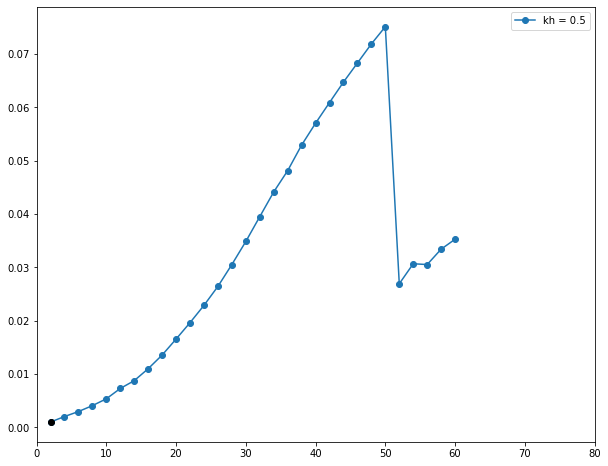

In [32]:
yplot = etotal_list
yplot = ebond_list
# yplot = epair_list

nmax = 61
khmin = 0
khmax = 2


fig, ax = plt.subplots(1,1,figsize=(10,8))
# ax.plot(x,y,"ro-")
khsla = []
nsla = []
for i in np.arange(len(yplot)):
    if (len(yplot[i]) > 0) and (khlist[i]<=khmax) and (khlist[i]>=khmin):
        ax.plot(np.array(nshells_good[i]),np.array(yplot[i])/np.array(nshells_good[i]),"o-",label=f"kh = {khlist[i]}")
        try:
            nmask = (np.array(nshells_good[i])<=nmax)
            imin = np.argmin( np.array(yplot[i])[nmask] / np.array(nshells_good[i])[nmask] )
#             if np.array(nshells_good[i])[nmask][imin] < nmax
            khsla.append(khlist[i])
            nsla.append(np.array(nshells_good[i])[nmask][imin])
            ax.plot(np.array(nshells_good[i])[imin],np.array(yplot[i])[imin]/np.array(nshells_good[i])[imin],"ko")
        except:
            pass
#         ax.plot(np.array(nshells_good[i]),np.array(yplot[i]),"o-",label=f"kh = {kh_list[i]}")

ax.legend(fontsize=10)
ax.set_xlim(0,80)
# ax.set_xlim(0,65)
# ax.set_xlim(40,65)
# ax.set_xlim(0,17)
# ax.set_ylim(0.025,0.035)
# ax.set_xlim(5,20)
# ax.set_ylim(-0.9,-0.8)
# ax.set_ylim(-0.89,-0.87)
# ax.set_ylim(-1.35,-1.25)

# ax.set_xlim(0,30)
# ax.set_ylim(-0.78,-0.7)

# ax.plot(x,y,"ro-")
# ax.plot(np.array(56),np.array(3.3618792)/56,"ro")

In [200]:
x,y = np.array(nshells_good[i]),np.array(yplot[i])/np.array(nshells_good[i])

In [201]:
 np.array(nshells_good[i])

array([ 2.,  4.,  6.,  8., 10., 12., 14., 16., 18., 20., 22., 24., 26.,
       28., 30.])

In [202]:
np.array(yplot[i])/np.array(nshells_good[i])

array([0.00283681, 0.00976196, 0.01906428, 0.02990242, 0.04109901,
       0.05233336, 0.06272577, 0.07194979, 0.07975662, 0.08620351,
       0.09141949, 0.09563689, 0.09899515, 0.10161439, 0.10357411])

In [169]:
### Plot one design, shape; multiple sigma (can do multiple kh)

source = "txt" # "local" = on local machine; "txt" = from text files imported from remote machine
# source = "local"
txt_dir = f"{PROJECT_ROOT}/jobs/paper3D/energies"
sigma_list = [0.25,0.3,0.35,0.410829,0.45,0.5,0.55,0.6,0.6367897,0.7,0.75,0.8,0.85,0.899922,0.95,1.,1.05]
kh_list = (1.6 * np.ones(len(sigma_list))).tolist()
# kh_list = "all"
nshells_list = np.arange(2,61,1)

##### PARTICLE #####
### Geometry
dimension = 3
dcore = 1.0    # hard core diameter of beads (dcore approx thickness of one DNA helix 3.5nm)
wx = 30 * dcore    # mesh width in x 
wy = 30 * dcore    # mesh width in y 
a = 0.316 * dcore    # lattice constant of mesh
mesh_name = f"a-{a:.3f}-wx-{wx:.2f}-wy-{wy:.2f}"    # name of bead-spring mesh to use for shell


### eta = 0.1
# sigma = 0.25*dcore
# sigma = 0.35
# sigma = 0.4108*dcore
# sigma = 0.5*dcore
# t0 = 4.434 * dcore    # structural thickness
# r0 = 54.053 * dcore   # RMS radius of curvature; set to "flat" for planar plates 

### eta = 0.9
# sigma = 0.25
# sigma = 0.4108*dcore
# t0 = 2.35 * dcore    
# r0 = 32.893 * dcore

### eta = 8.7
# sigma = 0.25*dcore
# sigma = 0.6368*dcore
# t0 = 1.2 * dcore    
# r0 = 21.221 * dcore  

### eta = 20
# sigma = 0.25*dcore
# sigma = 0.4108*dcore
# t0 = 0.8 * dcore    
# r0 = 21.221 * dcore

### eta = 35
# sigma = 0.25*dcore
# sigma = 0.4108*dcore
# sigma = 0.6368*dcore
t0 = 0.6 * dcore    
r0 = 21.221 * dcore

### eta = 70
# sigma = 0.25 * dcore
# sigma = 0.8999*dcore
# sigma = 0.410829 * dcore
# t0 = 0.6 * dcore    
# r0 = 15.015 * dcore  

# alpha = 0 * np.pi/180    # shape 'angle' (0 = cylinder w/ curvature in x; pi/4 = sphere; -pi/4 = saddle) 
alpha = 45 * np.pi/180
# alpha = -45 * np.pi/180
theta = 0    # angle principal direction 1 makes with material x-axis

if r0 == "flat":
    k_0 = 0
else:
    k_0 = 1/r0    # RMS curvature

# preferred curvatures
k01 = k_0 * np.cos(alpha)    # principal curvatures
k02 = k_0 * np.sin(alpha)
kx_0 = k01 * np.cos(theta)**2 + k02 * np.sin(theta)**2  # curvatures in material directions x, y, xy
ky_0 = k01 * np.sin(theta)**2 + k02 * np.cos(theta)**2
kxy_0 = (k01-k02) * np.sin(theta) * np.cos(theta)


### Elasticity
# kh = kh_list[j]
nuxy = 0.333
nuz = 0.001
kvkh = (3*(1-3*nuxy)*(1-nuxy-2*nuz*(t0/a)**2))/(2*nuz*(4*nuz*(t0/a)**2+3*nuxy-1))
kckh = ((1-3*nuxy)*(1+(t0/a)**2))/(4*nuz*(t0/a)**2+3*nuxy-1)

#         kvkh = 1 
#         kckh = 1 

### Interactions
pair_ints = "patchy" #"none", "repulsive", "1patch", "patchy", "attractive", or "2attractive"
soft_ints = False
# sigma = 0.25*dcore
# sigma = 0.4108*dcore
# sigma = 0.6368*dcore
# epsilon = 0
# shift = dcore - 2**(1/6)*sigma     # shift factor to make sure lj minimum is at dcore
# ljcut = 5*sigma #t0 + 2*dcore               # cutoff distance for attractive lj potential
# wcacut = dcore    # cutoff distance for repulsive wca potential
# softsigma = 5*sigma
# softepsilon = 5e-8 * epsilon
# softshift = 0 #softcore - 2**(1/6)*softsigma
# softcut = 2**(1/6) * softsigma

### Dynamics/Minimization Settings
minstyle = "cg"
etol = 1e-10
# etol = 1e-12
# etol = 1e-14
maxiter = 100000


etotal_list = []
ebond_list = []
epair_list = []
nshells_good = []
stop_list = []
e2_list = []
sigma_good = []
kh_good = []

for i in np.arange(len(sigma_list)):
    sigma = sigma_list[i]
    kh = kh_list[i]
    parentdir = f"data/paper3D/{int(dimension)}d/emin/{mesh_name}/t0-{t0:0.3f}-r0-{r0:0.3f}/alpha_{alpha*180/np.pi:0.3f}/sigma-{sigma:0.5f}" 

    etotal_i = []
    ebond_i = []
    epair_i = []
    nshells_i = []
    stop_i = []
    e2_i = []
    
    if source == "local":

        for j in np.arange(len(nshells_list)):
            try:
                nshells = nshells_list[j]
    #                     simpath = f"data/examples/{int(dimension)}d/emin/kh-{kh:0.2f}/nshells-{nshells}"
                simpath = f"data/examples/{int(dimension)}d/emin/{mesh_name}/t0-{t0:0.3f}-r0-{r0:0.3f}/alpha_{alpha*180/np.pi:0.3f}/sigma-{sigma:0.5f}/kh-{kh:0.2f}/nshells-{nshells}/{minstyle}-{int(np.abs(np.log10(etol)))}"
    #                 simpath = f"{parentdir}/kh-{kh:0.5f}/nshells-{nshells}/{minstyle}-{int(np.abs(np.log10(etol)))}" 
                logname = "log.lammps"
                result = ReadSim(f"{PROJECT_ROOT}/{simpath}")
                result.read_log(logname=logname)
                etotal_i.append(result.thermo_TotEng[-1])
                ebond_i.append(result.thermo_E_bond[-1])
                epair_i.append(result.thermo_E_pair[-1])
                nshells_i.append(nshells)
                stop_i.append(result.why_stop)
                e2_i.append(result.energy2)
            except:
                pass

        etotal_list.append(etotal_i)
        ebond_list.append(ebond_i)
        epair_list.append(epair_i)
        nshells_good.append(nshells_i)
        stop_list.append(stop_i)
        e2_list.append(e2_i)
    
    elif source == "txt":
        try:
            data = np.loadtxt(f"{txt_dir}/{mesh_name}-t0-{t0:0.3f}-r0-{r0:0.3f}-alpha_{alpha*180/np.pi:0.3f}-sigma-{sigma:0.5f}-kh-{kh:0.5f}-{minstyle}-{int(np.abs(np.log10(etol)))}.txt",skiprows=1,usecols=(0,1,2,3,4))
            try: 
                nshells_i = data[:,0].tolist()
                etotal_i = data[:,1].tolist()
                ebond_i = data[:,2].tolist()
                epair_i = data[:,3].tolist()
                e2_i = data[:,4].tolist()
            except:
                nshells_i = [data[0]]
                etotal_i = [data[1]]
                ebond_i = [data[2]]
                epair_i = [data[3]]
                e2_i = [data[4]]

            etotal_list.append(etotal_i)
            ebond_list.append(ebond_i)
            epair_list.append(epair_i)
            nshells_good.append(nshells_i)
    #         stop_list.append(stop_i)
            e2_list.append(e2_i)
            sigma_good.append(sigma)
            kh_good.append(kh)
        
        except:
            pass
        
        



(0.0, 80.0)

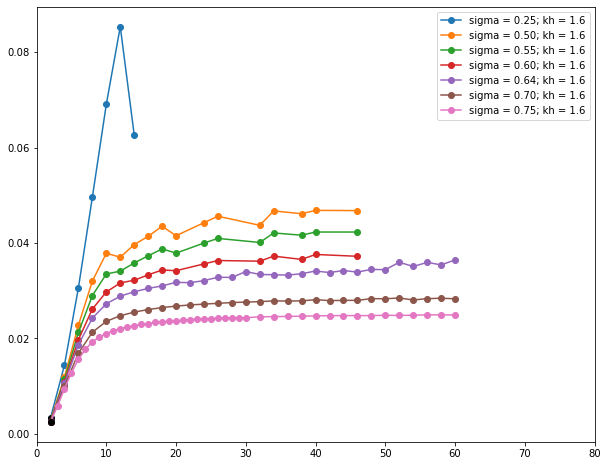

In [173]:
yplot = etotal_list
yplot = ebond_list
# yplot = epair_list

nmax = 59
sigmamin = 0.
sigmamax = 10


fig, ax = plt.subplots(1,1,figsize=(10,8))
# ax.plot(x,y,"ro-")
sigmasla = []
khsla = []
nsla = []
for i in np.arange(len(yplot)):
    if (len(yplot[i]) > 0) and (sigma_good[i]<=sigmamax) and (sigma_good[i]>=sigmamin):
        ax.plot(np.array(nshells_good[i]),np.array(yplot[i])/np.array(nshells_good[i]),"o-",label=f"sigma = {sigma_good[i]:0.2f}; kh = {kh_good[i]}")
        try:
            nmask = (np.array(nshells_good[i])<=nmax)
            imin = np.argmin( np.array(yplot[i])[nmask] / np.array(nshells_good[i])[nmask] )
#             if np.array(nshells_good[i])[nmask][imin] < nmax
            khsla.append(kh_good[i])
            sigmasla.append(sigma_good[i])
            nsla.append(np.array(nshells_good[i])[nmask][imin])
            ax.plot(np.array(nshells_good[i])[imin],np.array(yplot[i])[imin]/np.array(nshells_good[i])[imin],"ko")
        except:
            pass
#         ax.plot(np.array(nshells_good[i]),np.array(yplot[i]),"o-",label=f"kh = {kh_list[i]}")

ax.legend(fontsize=10)
ax.set_xlim(0,80)
# ax.set_xlim(0,65)
# ax.set_xlim(40,65)
# ax.set_xlim(0,17)
# ax.set_ylim(0.005,0.05)
# ax.set_xlim(5,20)
# ax.set_ylim(-0.9,-0.8)
# ax.set_ylim(-0.89,-0.87)
# ax.set_ylim(-1.35,-1.25)

# ax.set_xlim(0,30)
# ax.set_ylim(-0.78,-0.7)

# ax.plot(x,y,"ro-")
# ax.plot(np.array(56),np.array(3.3618792)/56,"ro")

# ax.vlines(32,ymin=0,ymax=1)

In [236]:
sigma_list

[0.25,
 0.3,
 0.35,
 0.410829,
 0.45,
 0.5,
 0.55,
 0.6,
 0.6367897,
 0.7,
 0.75,
 0.899922]

In [222]:
np.arange(2,61,2)

array([ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34,
       36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60])

In [407]:
nshells_good[i]

[2.0,
 4.0,
 6.0,
 8.0,
 10.0,
 12.0,
 14.0,
 16.0,
 18.0,
 20.0,
 22.0,
 24.0,
 26.0,
 28.0,
 34.0,
 36.0,
 40.0,
 42.0,
 44.0,
 46.0,
 48.0,
 50.0,
 52.0,
 56.0,
 58.0,
 60.0]

In [279]:
f"{txt_dir}/{mesh_name}-t0-{t0:0.3f}-r0-{r0:0.3f}-alpha_{alpha*180/np.pi:0.3f}-sigma-{sigma:0.5f}-kh-{kh:0.5f}-{minstyle}-{int(np.abs(np.log10(etol)))}.txt"

'/Users/kyle/Documents/Code/cgshells/jobs/paper3D/energies/a-0.316-wx-30.00-wy-30.00-t0-0.600-r0-21.221-alpha_45.000-sigma-0.75000-kh-1.60000-cg-10.txt'

In [19]:
np.array(nsla)

array([], dtype=float64)

In [252]:
np.flip(np.array(khsla))

array([1.6])

In [254]:
np.flip(np.arange(10)).tolist()

[9, 8, 7, 6, 5, 4, 3, 2, 1, 0]

In [730]:
np.array(nshells_good[i])[nmask][imin]

6.0

In [ ]:
sigma_list = [0.3, 0.35, 0.410829, 0.45, 0.5, 0.55, 0.6, 0.6367897, 0.7, 0.75]
sigma_loadlist = [0.25, 0.3, 0.35, 0.410829, 0.45, 0.5, 0.55, 0.6, 0.6367897, 0.7]
epsilon_list = [1.0422868180740177e-05, 8.583244858013735e-06, 7.149441531645948e-06, 6.466847477837022e-06, 5.764507277641722e-06, 5.1973129665786396e-06, 4.728320896676036e-06, 4.4305240601244645e-06, 3.991183857451125e-06, 3.696195866199495e-06]
epsilon_loadlist = [1.4464536457630208e-05, 1.0422868180740177e-05, 8.583244858013735e-06, 7.149441531645948e-06, 6.466847477837022e-06, 5.764507277641722e-06, 5.1973129665786396e-06, 4.728320896676036e-06, 4.4305240601244645e-06, 3.991183857451125e-06]

In [ ]:
sigma_list = [0.7, 0.6367897,0.6,0.55,0.5,0.45,0.410829,0.35,0.3,0.25]
sigma_loadlist = [0.75, 0.7, 0.6367897,0.6,0.55,0.5,0.45,0.410829,0.35,0.3,0.25]
epsilon_list = [3.991183857451125e-06, 4.4305240601244645e-06, 4.728320896676036e-06, 5.1973129665786396e-06, 5.764507277641722e-06, 6.466847477837022e-06, 7.149441531645948e-06, 8.583244858013735e-06, 1.0422868180740177e-05, 1.4464536457630208e-05]


In [52]:
i = -1
x=np.array(nshells_good[i])
y=np.array(yplot[i])/np.array(nshells_good[i])

In [272]:
stop_list

[]

In [ ]:
[0.1 , 0.105, 0.11, 0.115, 0.12, 0.125, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42, 0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 ]

# Inter-particle gaps

In [141]:
source = "txt" # "local" = on local machine; "txt" = from text files imported from remote machine
# kh_list = [10]
# nshells_list = [2,4,6,8,10]
# [0.25,0.3,0.35,0.410829,0.45,0.5,0.55,0.6,0.6367897,0.7,0.75,0.899922]
sigma = 0.5
# sigma = 0.6367897
# sigma = 0.899922
kh = 1.6
# nshells = 12
meshdesigns_dir = f"{PROJECT_ROOT}/data/3d/MeshDesigns"
gaptxt_dir = f"{PROJECT_ROOT}/jobs/paper3D/gaps"

##### PARTICLE #####
### Geometry
dimension = 3
dcore = 1.0    # hard core diameter of beads 
wx = 30 * dcore    # mesh width in x 
wy = 30 * dcore    # mesh width in y 
a = 0.316 * dcore    # lattice constant of mesh
mesh_name = f"a-{a:.3f}-wx-{wx:.2f}-wy-{wy:.2f}"    # name of bead-spring mesh to use for shell
t0 = 0.6 * dcore    # structural thickness
r0 = 21.221 * dcore   # RMS radius of curvature; set to "flat" for planar plates 
alpha = 45 * np.pi/180    # shape 'angle' (0 = cylinder w/ curvature in x; pi/4 = sphere; -pi/4 = saddle) 
theta = 0    # angle principal direction 1 makes with material x-axis

if r0 == "flat":
    k_0 = 0
else:
    k_0 = 1/r0    # RMS curvature

# preferred curvatures
k01 = k_0 * np.cos(alpha)    # principal curvatures
k02 = k_0 * np.sin(alpha)
kx_0 = k01 * np.cos(theta)**2 + k02 * np.sin(theta)**2  # curvatures in material directions x, y, xy
ky_0 = k01 * np.sin(theta)**2 + k02 * np.cos(theta)**2
kxy_0 = (k01-k02) * np.sin(theta) * np.cos(theta)


### Elasticity
# kh = 1
nuxy = 0.333
nuz = 0.001
kvkh = (3*(1-3*nuxy)*(1-nuxy-2*nuz*(t0/a)**2))/(2*nuz*(4*nuz*(t0/a)**2+3*nuxy-1))
kckh = ((1-3*nuxy)*(1+(t0/a)**2))/(4*nuz*(t0/a)**2+3*nuxy-1)

#         kvkh = 1 
#         kckh = 1 

### Interactions
pair_ints = "patchy" #"none", "repulsive", "1patch", "patchy", "attractive", or "2attractive"
soft_ints = False
# sigma = 0.5*dcore
# epsilon = 0
shift = dcore - 2**(1/6)*sigma     # shift factor to make sure lj minimum is at dcore
ljcut = 5*sigma #t0 + 2*dcore               # cutoff distance for attractive lj potential
wcacut = dcore    # cutoff distance for repulsive wca potential
# softsigma = 5*sigma
# softepsilon = 5e-8 * epsilon
# softshift = 0 #softcore - 2**(1/6)*softsigma
# softcut = 2**(1/6) * softsigma

### Dynamics/Minimization Settings
minstyle = "cg"
etol = 1e-10
maxiter = 100000

mesh_dir = "{}/{}".format(meshdesigns_dir,mesh_name)
ptx, pty = 0, 0    # find atom closest to this point
frame = -1   

if source == "local":

#     try:
#     simpath = f"data/examples/{int(dimension)}d/emin/kh-{kh:0.2f}/nshells-{nshells}"
#     simpath = f"data/examples/{int(dimension)}d/emin/{mesh_name}/t0-{t0:0.3f}-r0-{r0:0.3f}/alpha_{alpha*180/np.pi:0.3f}/sigma-{sigma:0.5f}/kh-{kh:0.2f}/nshells-{nshells}/{minstyle}-{int(np.abs(np.log10(etol)))}"
#     simpath = f"data/paper3D/{int(dimension)}d/emin/{mesh_name}/t0-{t0:0.3f}-r0-{r0:0.3f}/alpha_{alpha*180/np.pi:0.3f}/sigma-{sigma:0.5f}/kh-{kh:0.5f}/nshells-{nshells}/{minstyle}-{int(np.abs(np.log10(etol)))}" 
    simpath = "."
    result = ReadSim(f"{PROJECT_ROOT}/{simpath}")
    files = result.files
#     dumpname = "nshells-16.dump.gz"#latest_traj(files)
#     dumpname = "trajectory1.dump.gz"
    dumpname = "nshells10.dump.gz"
#     dumpname = "eta-35-a-45-sigma-0.5-kh-1.6-nshells-12.dump.gz"
    rmx,rmy,rmz,dists = find_midlayer_pt_3d(mesh_dir,f"{PROJECT_ROOT}/{simpath}",dumpname,ptx,pty,frame)
#     except:
#         pass
                
if source == "txt":
    data = np.loadtxt(f"{gaptxt_dir}/{mesh_name}-t0-{t0:0.3f}-r0-{r0:0.3f}-alpha_{alpha*180/np.pi:0.3f}-sigma-{sigma:0.5f}-kh-{kh:0.5f}-{minstyle}-{int(np.abs(np.log10(etol)))}.txt",skiprows=1)
            
    


(1.4400000000000002, 1.6800000000000002)

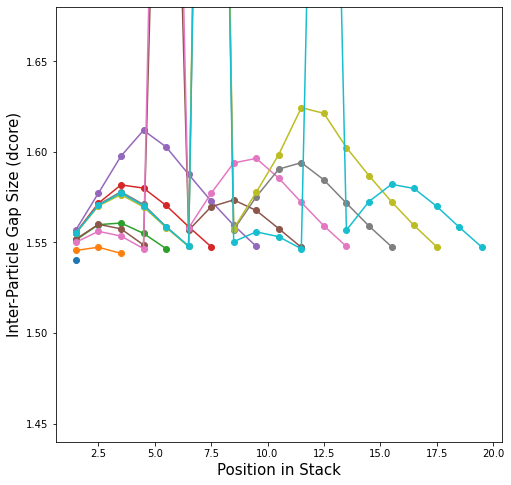

In [142]:
fig, ax = plt.subplots(1,1,figsize=(8,8))

nmin = 0
nmax = 20

if source == "txt":
    dists = data[:,1:]
    nshells = data[:,0]
    for i in np.arange(len(nshells)):
        if (nshells[i]>=nmin) and (nshells[i]<=nmax):
            distmask = (dists[i]>0)
            ax.plot(np.arange(int(nshells[i]-1))+1.5,dists[i][distmask],"o-")
    
if source == "local":
    ax.plot(np.arange(len(dists))+0.5,dists,"o")
# ax.set_xlim(0,len(dists))
# ax.set_xlim(-1,61)
ax.set_xlabel("Position in Stack",fontsize=15)
ax.set_ylabel("Inter-Particle Gap Size (dcore)",fontsize=15)

ax.set_ylim(0.9*(t0+dcore),1.05*(t0+dcore))

In [365]:
nshells

array([ 2.,  4.,  6.,  8., 10., 12., 14., 16., 18., 20., 24., 26., 32.,
       34., 38., 40., 46.])

(-15.0, 15.0)

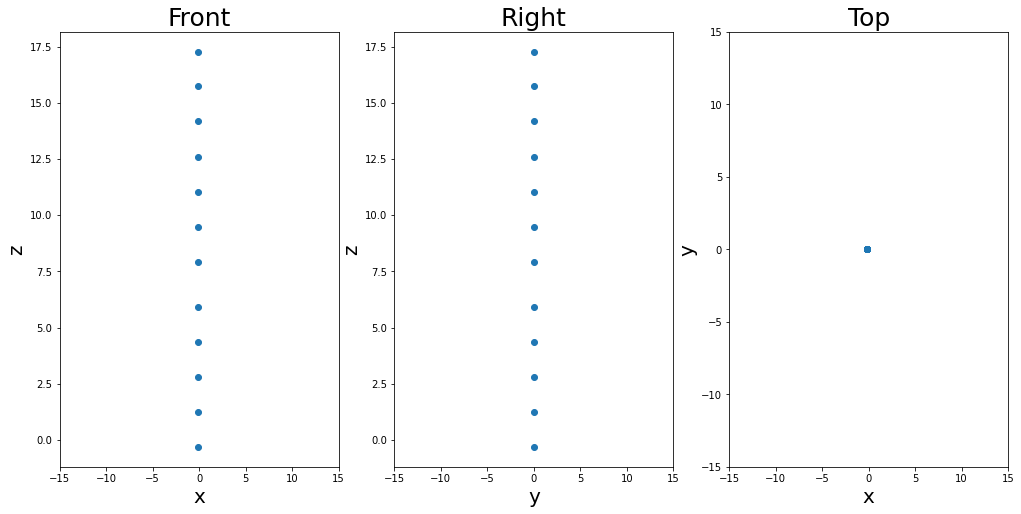

In [300]:
fig, [ax1,ax2,ax3] = plt.subplots(1,3,figsize=(17,8))

ax1.set_title("Front", fontsize = 25)
ax1.set_xlabel("x",fontsize=20)
ax1.set_ylabel("z",fontsize=20)
ax1.plot(rmx,rmz,"o")
ax1.set_xlim(-wx/2,wx/2)

ax2.set_title("Right", fontsize = 25)
ax2.set_xlabel("y",fontsize=20)
ax2.set_ylabel("z",fontsize=20)
ax2.plot(rmy,rmz,"o")
ax2.set_xlim(-wy/2,wy/2)

ax3.set_title("Top", fontsize = 25)
ax3.set_xlabel("x",fontsize=20)
ax3.set_ylabel("y",fontsize=20)
ax3.plot(rmx,rmy,"o")
ax3.set_xlim(-wx/2,wx/2)
ax3.set_ylim(-wy/2,wy/2)

Text(0, 0.5, 'Inter-Particle Gap Size (dcore)')

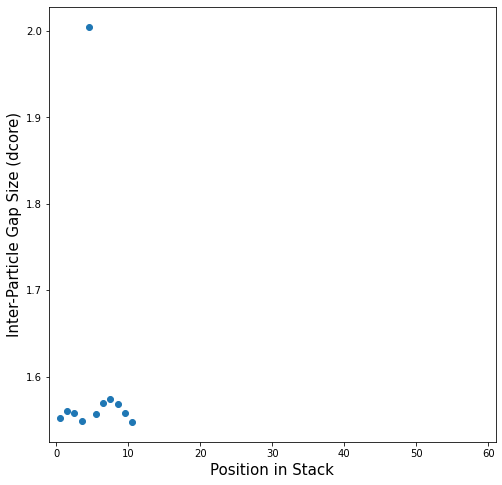

In [301]:
fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.plot(np.arange(len(dists))+0.5,dists,"o")
# ax.set_xlim(0,len(dists))
ax.set_xlim(-1,61)
ax.set_xlabel("Position in Stack",fontsize=15)
ax.set_ylabel("Inter-Particle Gap Size (dcore)",fontsize=15)



# tmin = 2.95
# ax.plot(np.arange(len(dists))+0.5,dists/tmin,"o-")
# ax.set_xlim(0,len(dists))
# # ax.set_ylim(0.99,1.05)
# ax.set_xlabel("Position in Stack",fontsize=15)
# ax.set_ylabel("Inter-Particle Gap Size / tmin",fontsize=15)

# delta = tmin*kx_0**2*wx**2/8
# ax.plot(np.arange(len(dists))+0.5,(dists-tmin)/(delta),"o-")
# ax.set_xlim(0,len(dists))
# # ax.set_ylim(0.99,1.05)
# ax.set_xlabel("Position in Stack",fontsize=15)
# ax.set_ylabel("Inter-Particle Gap Size / delta",fontsize=15)

In [332]:
dists

array([1.55185969, 1.56001827, 1.55752019, 1.5486551 , 2.00507007,
       1.55672004, 1.56973007, 1.57350008, 1.56765007, 1.55765009,
       1.54730018])

In [333]:
nshells_list

array([ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34,
       36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60])

In [344]:
gapinfo = " ".join(np.array(gaps,dtype=str))

In [346]:
f"{nshells_list[-1]} {gapinfo}"

'60 1.5518596902853363 1.5600182677520158 1.5575201878707707 1.5486551007074654 2.0050700736613294 1.5567200438518976 1.5697300741548688 1.573500080396883 1.5676500747156557 1.5576500854672066 1.54730017791119 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0 -1.0'

In [335]:
gaps = -1 * np.ones(np.max(nshells_list))
gaps[:len(dists)] = dists

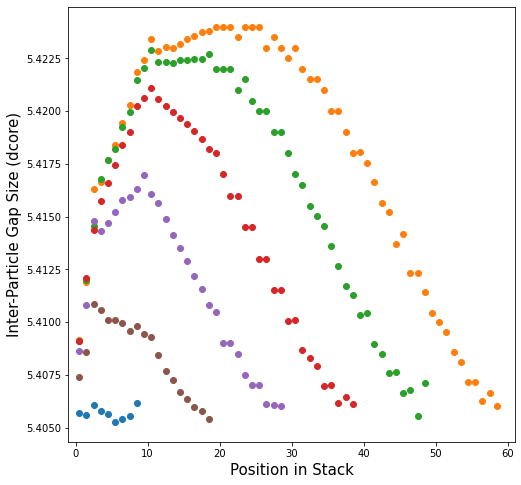

In [2030]:
fig, ax = plt.subplots(1,1,figsize=(8,8))
ax.plot(np.arange(len(dists))+0.5,dists,"o")
# ax.set_xlim(0,len(dists))
ax.set_xlim(-1,61)
ax.set_xlabel("Position in Stack",fontsize=15)
ax.set_ylabel("Inter-Particle Gap Size (dcore)",fontsize=15)

ax.plot(x,y,"o")
# ax.plot(x1,y1,"o")
# ax.plot(x2,y2,"o")
# ax.plot(x3,y3,"o")
# ax.plot(x4,y4,"o")




# tmin = 2.95
# ax.plot(np.arange(len(dists))+0.5,dists/tmin,"o-")
# ax.set_xlim(0,len(dists))
# # ax.set_ylim(0.99,1.05)
# ax.set_xlabel("Position in Stack",fontsize=15)
# ax.set_ylabel("Inter-Particle Gap Size / tmin",fontsize=15)

# delta = tmin*kx_0**2*wx**2/8
# ax.plot(np.arange(len(dists))+0.5,(dists-tmin)/(delta),"o-")
# ax.set_xlim(0,len(dists))
# # ax.set_ylim(0.99,1.05)
# ax.set_xlabel("Position in Stack",fontsize=15)
# ax.set_ylabel("Inter-Particle Gap Size / delta",fontsize=15)

In [2003]:
dumpname

'nshells60.dump.gz'

In [2027]:
x4 = np.arange(len(dists))+0.5
y4 = dists

In [2023]:
x3 = np.arange(len(dists))+0.5
y3 = dists

In [2019]:
x2 = np.arange(len(dists))+0.5
y2 = dists

In [2015]:
x1 = np.arange(len(dists))+0.5
y1 = dists

In [2005]:
x = np.arange(len(dists))+0.5
y = dists

In [155]:
delta

NameError: name 'delta' is not defined

## Write new trajectory file with total shell bond energies

In [40]:
### Simulation Variables
dcore = 1.0    # hard core diameter of beads 
wx = 30 * dcore    # mesh width in x 
wy = 30 * dcore    # mesh width in y 
a = 0.316 * dcore    # lattice constant of mesh
mesh_name = f"a-{a:.3f}-wx-{wx:.2f}-wy-{wy:.2f}"    # name of bead-spring mesh to use for shell

alpha = 0 * np.pi/180    # shape 'angle' (0 = cylinder w/ curvature in x; pi/4 = sphere; -pi/4 = saddle) 
# alpha = 45 * np.pi/180
# alpha = -45 * np.pi/180

### eta = 0.1
# t0 = 4.434 * dcore    
# r0 = 54.053 * dcore

### eta = 0.9
# t0 = 2.35 * dcore    
# r0 = 32.893 * dcore

### eta = 8.7
# t0 = 1.2 * dcore    
# r0 = 21.221 * dcore  

### eta = 20
# t0 = 0.8 * dcore    
# r0 = 21.221 * dcore

### eta = 35
t0 = 0.6 * dcore    
r0 = 21.221 * dcore

sigma = 0.25 * dcore
kh = 1.0
nshells = 2


### Read bond dump file
simdir = f"{PROJECT_ROOT}/data/paper3D/visuals/{mesh_name}/t0-{t0:0.3f}-r0-{r0:0.3f}/alpha_{alpha*180/np.pi:0.3f}/sigma-{sigma:0.5f}/kh-{kh:0.5f}/nshells-{int(nshells)}"
dumpname = "bonds.dump.gz"
readall = False
result = ReadSim(simdir)
result.read_dump(dumpname=dumpname,readall=readall)

### Find total bond energy for each shell
frame = 0
natomspershell = int(np.max([np.max(result.dump_c_batom1[0])/nshells, np.max(result.dump_c_batom2[0])/nshells]))
shellids = (result.dump_c_batom1[frame]//natomspershell)+1
shell_energies = []
for shell in np.arange(1,nshells+1,1):
    smask = (shellids == shell)
    shell_energy = np.sum(result.dump_c_bpot[frame][smask])
    shell_energies.append(shell)
    shell_energies.append(shell_energy)
shell_energies = np.array(shell_energies).reshape(nshells,2)

### Read last trajectory file
# dumpname = result.latest_file(file="trajectory")
dumpname = "trajectory1.dump.gz"
result.read_dump(dumpname=dumpname,readall=readall)

### Write new trajectory file with additional column for shell bond energies
contents = f"""ITEM: TIMESTEP
{result.tsteps[frame]}
ITEM: NUMBER OF ATOMS
{result.natoms}
ITEM: BOX BOUNDS {result.boundary_types[0]} {result.boundary_types[1]} {result.boundary_types[2]}
{result.xlo} {result.xhi}
{result.ylo} {result.yhi}
{result.zlo} {result.zhi}
ITEM: ATOMS {result.dump_labels[0]} {result.dump_labels[1]} {result.dump_labels[2]} {result.dump_labels[3]} {result.dump_labels[4]} {result.dump_labels[5]} shellbonds
"""

data = result.dumps[frame]
for i in range(result.natoms):   
    contents += f"{int(data[i,0])} {int(data[i,1])} {int(data[i,2])} {data[i,3]} {data[i,4]} {data[i,5]} {shell_energies[int(data[i,0])-1,1]}\n"
    
with open(f"{simdir}/trajectory_post.dump", "w") as f:
    f.write(contents)

(-1.5, 1.5)

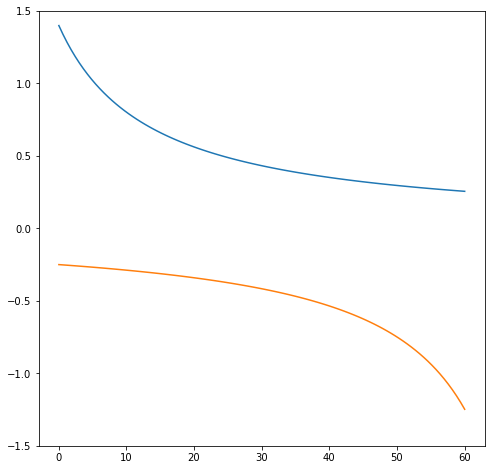

In [317]:
# t0 = 4.434 * dcore    # structural thickness
# r0 = 54.053 * dcore   # RMS radius of curvature; set to "flat" for planar plates 

# t0 = 2.35 * dcore    
# r0 = 32.893 * dcore

# t0 = 1.2 * dcore    
# r0 = 21.221 * dcore  

# t0 = 0.8 * dcore    
# r0 = 21.221 * dcore 

t0 = 0.6 * dcore    
r0 = 21.221 * dcore 

# t0 = 0.6 * dcore    
# r0 = 15.015 * dcore 

alpha = -45 * np.pi/180    # shape 'angle' (0 = cylinder w/ curvature in x; pi/4 = sphere; -pi/4 = saddle) 

if r0 == "flat":
    k_0 = 0
else:
    k_0 = 1/r0    # RMS curvature

# preferred curvatures
k01 = k_0 * np.cos(alpha)    # principal curvatures
k02 = k_0 * np.sin(alpha)

ki1 = 1.4 * k01    # principal curvatures for bottom shell in stack
ki2 = 0.25 * k02

# ki1 = 1.2 * k01    # principal curvatures for bottom shell in stack
# ki2 = 1.2 * k02

n = np.linspace(0.01,60,100)
# n = np.linspace(0.01,30,100)



fig, ax = plt.subplots(1,1,figsize = (8,8))
ax.plot(n,(ki1/(1+n*(t0+1)*ki1))/np.abs(k01),"-")
ax.plot(n,(ki2/(1+n*(t0+1)*ki2))/np.abs(k02),"-")
ax.set_ylim(-1.5,1.5)